In [10]:
# =============================================================================
# CONFIGURATION & IMPORTS
# =============================================================================

# Configuration
TRIAL_NUMBER = 10  # Trial to analyze (has real movement data)
TIME_BIN_SIZE = 0.05  # seconds (50 ms bins) - better for spike detection
SAMPLING_RATE = 30000  # Hz
SPIKE_CHANNELS = [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]

# Spike detection parameters
THRESHOLD_FACTOR = 5.0  # Spike detection threshold
SPIKE_WINDOW = (-10, 32)  # samples around spike

# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Modular imports - Updated to use spike detection
from utils.diagnostics import (
    diagnose_trial_data, 
    check_behavioral_data_availability,
    find_trials_with_movement,
    run_comprehensive_diagnostic
)
from utils.analysis import (
    SpikeAnalyzer,
    print_spike_summary
)
from utils.visualization import (
    plot_behavior_raster_psth,
    plot_spike_raster_behavioral,
    plot_spike_firing_rates,
    plot_spike_channel_comparison,
    plot_spike_channel_detail
)

# Set up plotting
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

print(f"🧠 Neural Feature Exploration with Spike Detection")
print(f"📊 Configuration: Trial {TRIAL_NUMBER}, {TIME_BIN_SIZE*1000:.0f}ms bins, {len(SPIKE_CHANNELS)} channels")
print(f"🔍 Spike detection: {THRESHOLD_FACTOR}x threshold, {SPIKE_WINDOW} sample window")


🧠 Neural Feature Exploration with Spike Detection
📊 Configuration: Trial 10, 50ms bins, 21 channels
🔍 Spike detection: 5.0x threshold, (-10, 32) sample window


In [11]:
# Initialize spike analyzer
spike_analyzer = SpikeAnalyzer(
    spike_channels=SPIKE_CHANNELS,
    sampling_rate=SAMPLING_RATE,
    threshold_factor=THRESHOLD_FACTOR,
    spike_window=SPIKE_WINDOW,
    bin_size=TIME_BIN_SIZE
)

print(f"✅ Spike analyzer initialized successfully!")


🔧 Filters initialized (300-3000 Hz bandpass, 500 Hz highpass)
🔍 SpikeDetector initialized:
  • Sampling rate: 30.0 kHz
  • Threshold factor: 5.0
  • Spike window: (-10, 32)
  • Good channels: 21
🔗 NeuralBehavioralAligner initialized:
  • Bin size: 50ms
  • Interpolation: linear
🔍 SpikeAnalyzer initialized:
  • 21 channels
  • 5.0x threshold
  • 50ms bins
✅ Spike analyzer initialized successfully!


In [12]:
# Run basic diagnostics and find trials with movement
print("🔍 Running diagnostics...")

# Check behavioral data availability
behavioral_summary = check_behavioral_data_availability(max_trials=20)

# Find trials with movement
movement_trials = find_trials_with_movement(min_movement_threshold=0.01, max_trials=20)

# Diagnose specific trial
trial_data = diagnose_trial_data(TRIAL_NUMBER, SAMPLING_RATE)

if trial_data:
    print(f"\n✅ Trial {TRIAL_NUMBER} diagnostics passed!")
    print(f"🎯 Recommended trials with good movement:")
    print(f"   {movement_trials[:10]}")  # Show first 10 trials with movement
else:
    print("❌ Trial diagnostic failed!")
    trial_data = None


🔍 Running diagnostics...

🔍 CHECKING BEHAVIORAL DATA AVAILABILITY (first 20 trials):
--------------------------------------------------
Trial  Neural  Vel_X   Vel_Y   Timestamps  Outcome  VelX Shape   VelX Range          
----------------------------------------------------------------------------------------------------
1      ✅       ✅       ✅       ✅           lose     (1407,)      -0.496 to 0.724     
2      ✅       ✅       ✅       ✅           win      (106,)       -0.406 to 0.503     
3      ✅       ✅       ✅       ✅           win      (133,)       -0.384 to 0.214     
4      ✅       ✅       ✅       ✅           win      (120,)       -0.660 to 0.243     
5      ✅       ✅       ✅       ✅           win      (175,)       -0.666 to 0.000     
6      ✅       ✅       ✅       ✅           win      (68,)        0.000 to 0.965      
7      ✅       ✅       ✅       ✅           win      (96,)        -0.812 to 0.000     
8      ✅       ✅       ✅       ✅           win      (94,)        -0.703 to 

In [13]:
# Perform spike analysis using the modular analyzer
print(f"🔍 Analyzing trial {TRIAL_NUMBER} with spike detection...")

# Analyze trial using modular spike analyzer
analysis_results = spike_analyzer.analyze_trial(TRIAL_NUMBER)

if analysis_results['success']:
    print(f"✅ Spike analysis completed successfully!")
    
    # Display comprehensive summary
    print_spike_summary(analysis_results)
    
    # Get summary statistics
    summary_stats = spike_analyzer.get_summary_statistics(analysis_results)
    print(f"\n📈 Summary Statistics:")
    for key, value in summary_stats.items():
        print(f"   • {key}: {value}")
    
    # Analyze neural-behavioral correlation
    correlation_analysis = spike_analyzer.analyze_neural_behavioral_correlation(analysis_results)
    if correlation_analysis['success']:
        print(f"\n🧠 Neural-Behavioral Correlation:")
        print(f"   • Population correlation: {correlation_analysis['population_correlation']:.3f}")
        print(f"   • Top channels correlations:")
        for channel, corr in correlation_analysis['channel_correlations']:
            print(f"     - Channel {channel}: {corr:.3f}")
    
else:
    print(f"❌ Spike analysis failed: {analysis_results.get('error', 'Unknown error')}")
    analysis_results = None


🔍 Analyzing trial 10 with spike detection...
🔍 Analyzing trial 10...
🔍 Extracting spike features from trial 10
🔍 Detecting spikes across 21 channels...
🔧 Preprocessing neural data: (96, 93372)
✅ Signal preprocessing complete
✅ Spike detection complete: 900 spikes across 21 channels
🔥 Computing firing rates (bin size: 50ms)
✅ Firing rates computed: 59 bins x 21 channels
✅ Features extracted for trial 10
📂 Loading trial 10 data...
✅ Trial 10 loaded:
  • Neural data: (96, 93372)
  • Velocity data: 114 samples
  • Duration: 2.91s
🔍 Detecting spikes across 21 channels...
🔧 Preprocessing neural data: (96, 93372)
✅ Signal preprocessing complete
✅ Spike detection complete: 900 spikes across 21 channels
✅ Trial 10 analysis complete!
✅ Spike analysis completed successfully!
📊 SPIKE ANALYSIS SUMMARY
🔍 Detection Results:
   • Total channels analyzed: 21
   • Total spikes detected: 900
   • Mean firing rate: 13.5 Hz
   • Active channels (>50 spikes): 8

⭐ Quality Assessment:
   • Mean SNR: 6.84
   

📊 Creating comprehensive spike raster and behavioral visualization...
🎨 Creating enhanced behavior-raster-PSTH plot for trial 10...
🔍 Detecting spikes for enhanced raster plot...
📊 Computing PSTH...
🎯 Creating enhanced vertline raster plot...


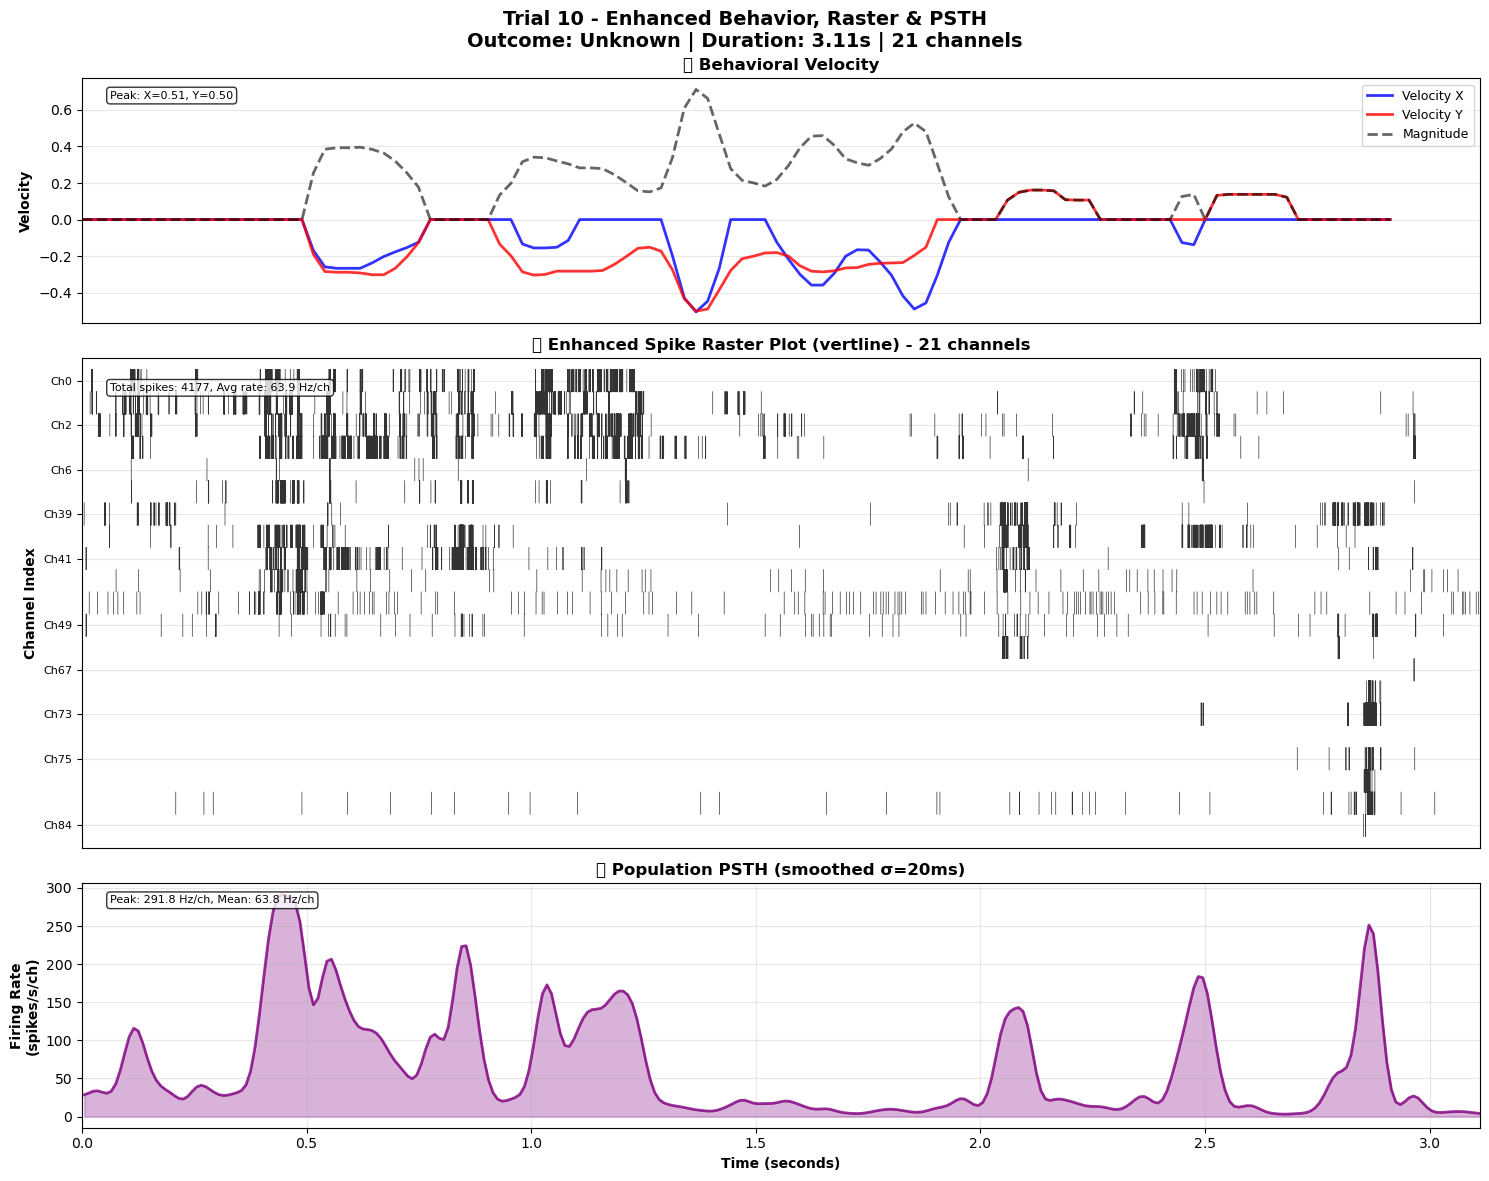


📊 Enhanced Trial 10 Summary:
   Neural data: 96 channels, 93372 samples
   Spike detection: 4177 spikes detected
   Average firing rate: 63.91 Hz per channel
   Raster plot type: vertline
   PSTH resolution: 10.0ms bins, smoothed with σ=20ms
   Behavioral data: 114 samples
   Velocity peaks: X=0.505, Y=0.501
   Most active channels: ['Ch2(629)', 'Ch3(626)', 'Ch1(500)', 'Ch0(475)', 'Ch41(379)']


In [14]:
# 1. Comprehensive spike raster and behavioral visualization
if analysis_results is not None and analysis_results['success']:
    print("📊 Creating comprehensive spike raster and behavioral visualization...")
    
    # Use modular visualization - fixed function call
    plot_behavior_raster_psth(
        analysis_results['trial_data'], 
        SPIKE_CHANNELS,  # Pass the spike channels list (not firing_rates)
        trial_number=TRIAL_NUMBER
    )
    
    # Alternative: Use new spike-based raster plot
    # plot_spike_raster_behavioral(analysis_results, TRIAL_NUMBER)
    
else:
    print("❌ Cannot create visualization - no valid analysis results")

📊 Creating individual channel firing rate analysis...


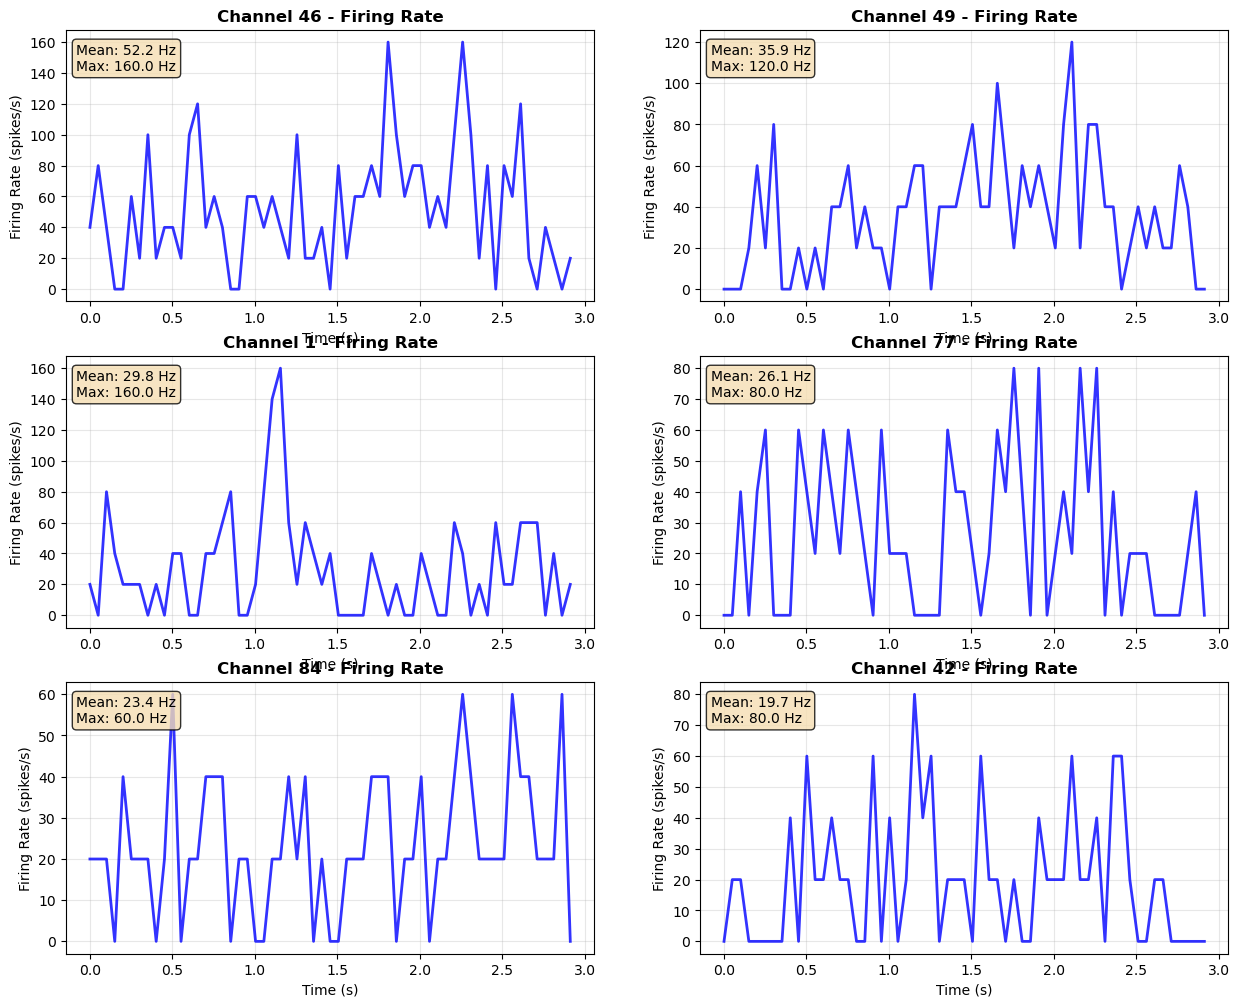

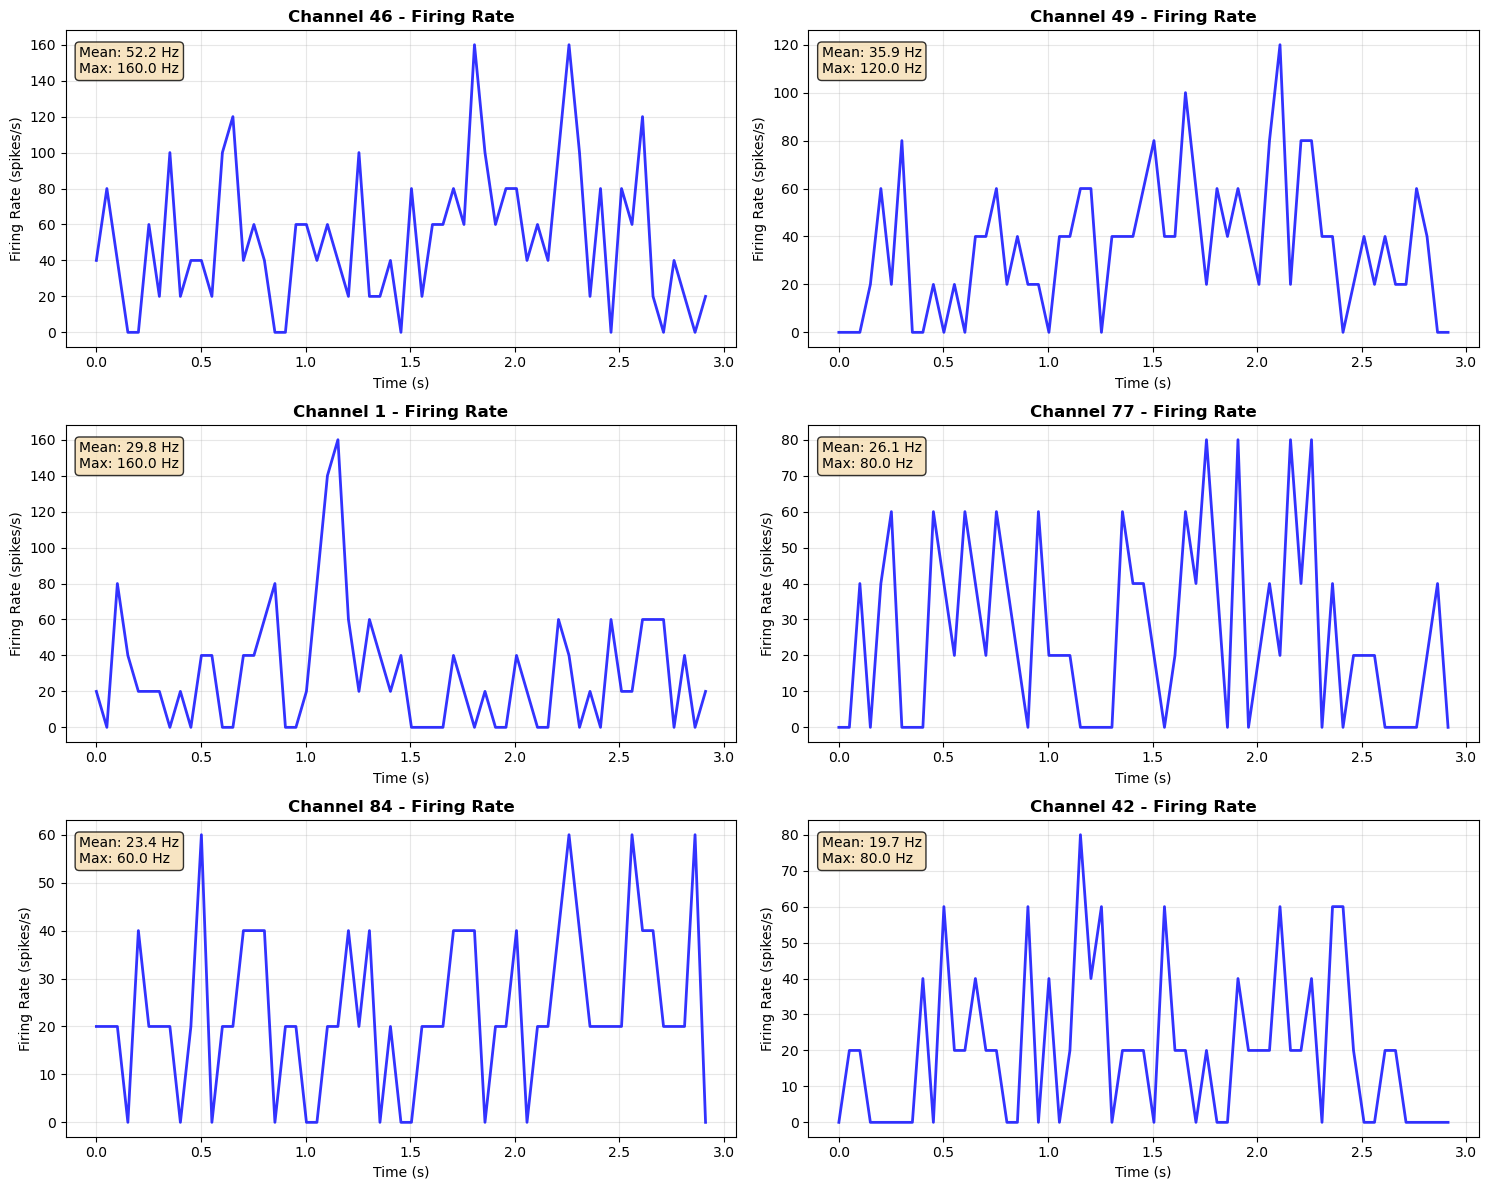

✅ Individual channel analysis complete!
   • Channels analyzed: 6


In [20]:
# 2. Individual channel firing rate analysis
if analysis_results is not None and analysis_results['success']:
    print("📊 Creating individual channel firing rate analysis...")
    
    # Use modular visualization function
    plot_spike_firing_rates(analysis_results, n_channels=6)
    
else:
    print("❌ Cannot create visualization - no valid analysis results")


📊 Creating channel comparison and spike statistics...


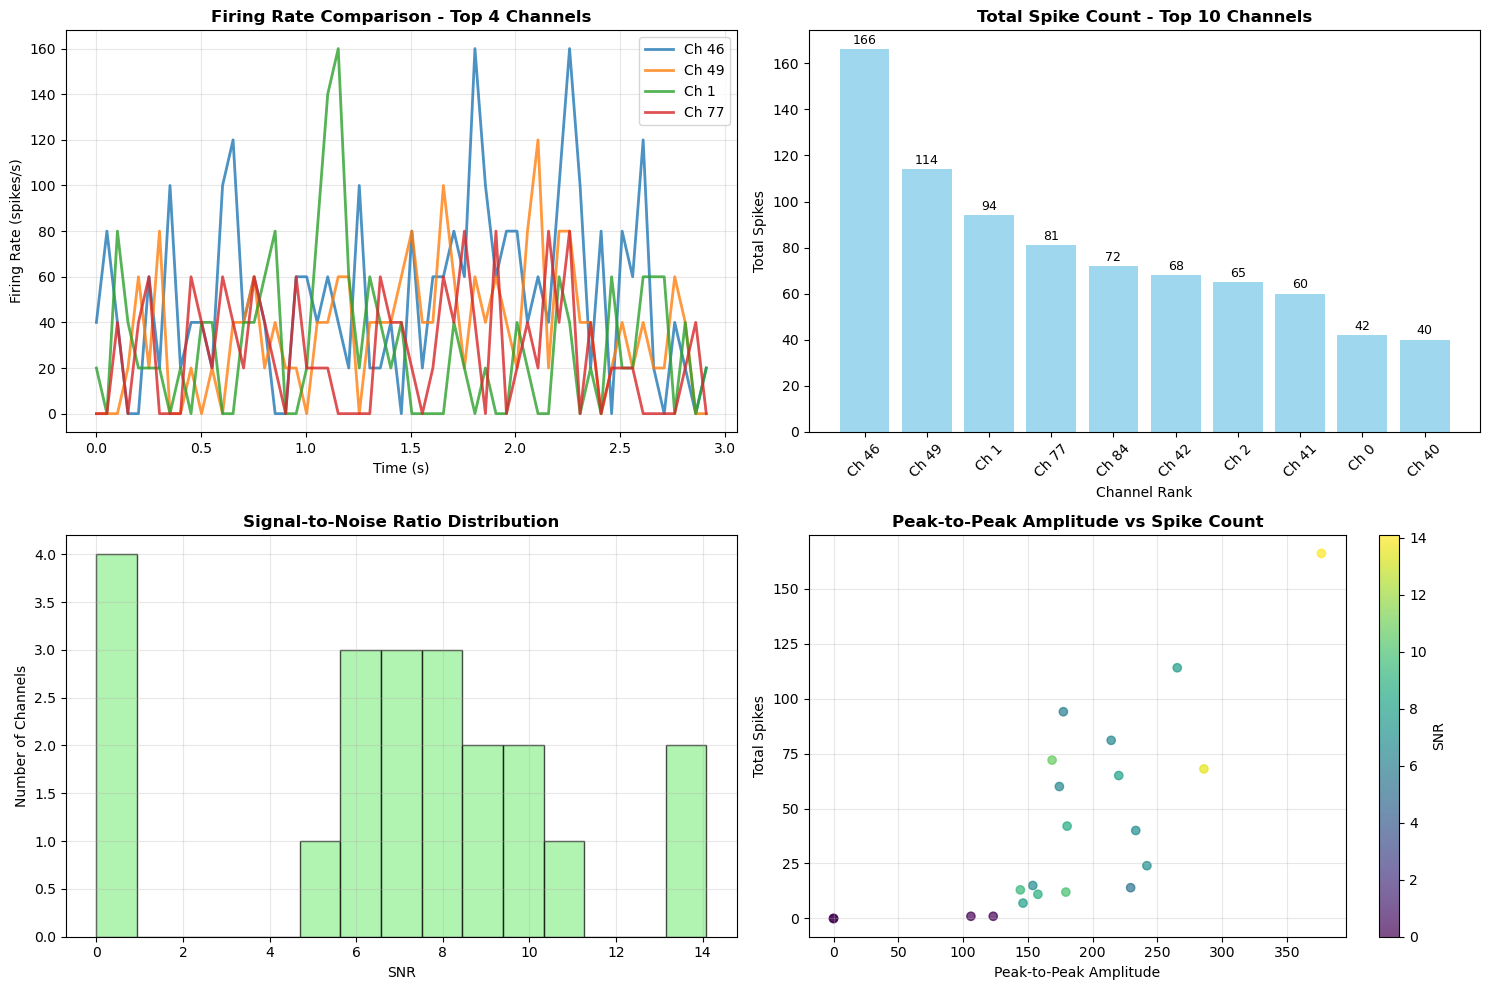

✅ Channel comparison complete!
   • Channels compared: 4
   • Quality metrics: 21 channels


In [16]:
# 3. Channel comparison and spike statistics
if analysis_results is not None and analysis_results['success']:
    print("📊 Creating channel comparison and spike statistics...")
    
    # Use modular visualization function
    plot_spike_channel_comparison(analysis_results)
    
else:
    print("❌ Cannot create visualization - no valid analysis results")


📊 Creating detailed analysis of the most active channel...
📊 Detailed analysis of most active channel: 46


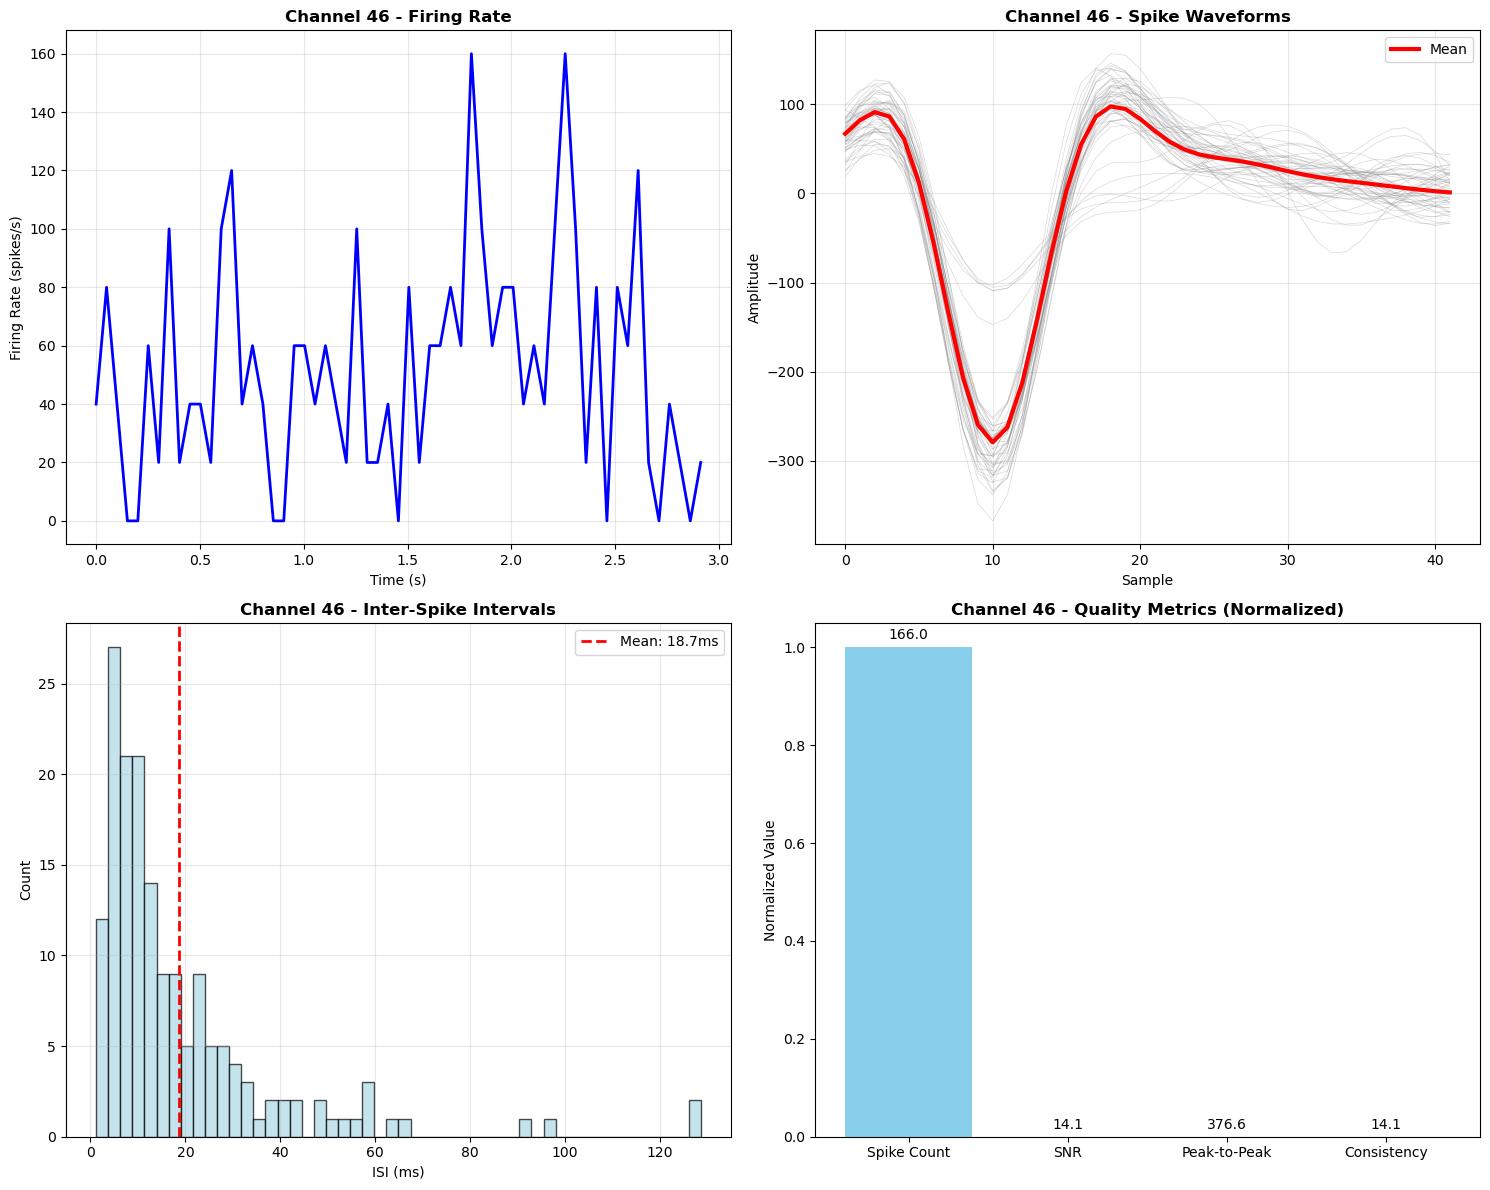

✅ Detailed analysis complete for channel 46!
   • Total spikes: 166
   • Mean firing rate: 52.2 Hz
   • Peak firing rate: 160.0 Hz


In [17]:
# 4. Detailed analysis of the most active channel
if analysis_results is not None and analysis_results['success']:
    print("📊 Creating detailed analysis of the most active channel...")
    
    # Use modular visualization function
    plot_spike_channel_detail(analysis_results)
    
else:
    print("❌ Cannot create visualization - no valid analysis results")


In [18]:
# 4. Detailed analysis of the most active channel
if firing_rates is not None and spike_data is not None and top_channels:
    most_active_channel = top_channels[0]
    print(f"📊 Detailed analysis of most active channel: {most_active_channel}")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Firing rate over time
    ax1 = axes[0, 0]
    if most_active_channel in firing_rates:
        time_bins = np.linspace(0, trial_data['metadata']['duration'], len(firing_rates[most_active_channel]))
        ax1.plot(time_bins, firing_rates[most_active_channel], 'b-', linewidth=2)
        ax1.set_title(f'Channel {most_active_channel} - Firing Rate', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Firing Rate (spikes/s)')
        ax1.grid(True, alpha=0.3)
    
    # Plot 2: Spike waveforms
    ax2 = axes[0, 1]
    if most_active_channel in spike_data:
        waveforms = spike_data[most_active_channel]['spike_waveforms']
        if len(waveforms) > 0:
            # Plot individual waveforms (sample)
            n_sample = min(50, len(waveforms))
            sample_indices = np.random.choice(len(waveforms), n_sample, replace=False)
            
            for i in sample_indices:
                ax2.plot(waveforms[i], 'gray', alpha=0.3, linewidth=0.5)
            
            # Plot mean waveform
            mean_waveform = np.mean(waveforms, axis=0)
            ax2.plot(mean_waveform, 'r-', linewidth=3, label='Mean')
            ax2.set_title(f'Channel {most_active_channel} - Spike Waveforms', fontsize=12, fontweight='bold')
            ax2.set_xlabel('Sample')
            ax2.set_ylabel('Amplitude')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
    
    # Plot 3: Inter-spike interval histogram
    ax3 = axes[1, 0]
    if most_active_channel in spike_data:
        spike_times = spike_data[most_active_channel]['spike_times']
        if len(spike_times) > 1:
            isis = np.diff(spike_times) / SAMPLING_RATE * 1000  # Convert to milliseconds
            ax3.hist(isis, bins=50, color='lightblue', alpha=0.7, edgecolor='black')
            ax3.set_title(f'Channel {most_active_channel} - Inter-Spike Intervals', fontsize=12, fontweight='bold')
            ax3.set_xlabel('ISI (ms)')
            ax3.set_ylabel('Count')
            ax3.grid(True, alpha=0.3)
            
            # Add statistics
            ax3.axvline(np.mean(isis), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(isis):.1f}ms')
            ax3.legend()
    
    # Plot 4: Channel quality metrics
    ax4 = axes[1, 1]
    if most_active_channel in quality_metrics['channel'].values:
        ch_metrics = quality_metrics[quality_metrics['channel'] == most_active_channel].iloc[0]
        
        metrics_names = ['Spike Count', 'SNR', 'Peak-to-Peak', 'Consistency']
        metrics_values = [ch_metrics['n_spikes'], ch_metrics['snr'], 
                         ch_metrics['peak_to_peak'], ch_metrics['consistency']]
        
        # Normalize values for comparison (0-1 scale)
        normalized_values = []
        for i, value in enumerate(metrics_values):
            if i == 0:  # Spike count
                normalized_values.append(value / quality_metrics['n_spikes'].max())
            else:
                max_val = quality_metrics[['snr', 'peak_to_peak', 'consistency']].max().max()
                normalized_values.append(value / max_val if max_val > 0 else 0)
        
        bars = ax4.bar(metrics_names, normalized_values, color=['skyblue', 'lightgreen', 'orange', 'pink'])
        ax4.set_title(f'Channel {most_active_channel} - Quality Metrics (Normalized)', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Normalized Value')
        
        # Add actual values as text
        for bar, actual_value in zip(bars, metrics_values):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{actual_value:.1f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Detailed analysis complete for channel {most_active_channel}!")
    if most_active_channel in spike_data:
        print(f"   • Total spikes: {spike_data[most_active_channel]['n_spikes']}")
        print(f"   • Mean firing rate: {np.mean(firing_rates[most_active_channel]):.1f} Hz")
        print(f"   • Peak firing rate: {np.max(firing_rates[most_active_channel]):.1f} Hz")


NameError: name 'firing_rates' is not defined

In [ ]:
# Analyze neural-behavioral correlation using spike data
if trial_data is not None and firing_rates is not None:
    print("🔗 NEURAL-BEHAVIORAL CORRELATION ANALYSIS:")
    print("=" * 50)
    
    # Check if we have behavioral data
    if (trial_data['velocity_x'] is not None and 
        trial_data['velocity_y'] is not None and 
        len(trial_data['velocity_x']) > 0):
        
        # Calculate velocity magnitude
        velocity_magnitude = np.sqrt(trial_data['velocity_x']**2 + trial_data['velocity_y']**2)
        
        # Calculate population firing rate
        duration = trial_data['metadata']['duration']
        time_bins = np.linspace(0, duration, len(list(firing_rates.values())[0]))
        
        population_rate = np.zeros(len(time_bins))
        for channel, rates in firing_rates.items():
            population_rate += rates
        
        # Align behavioral data to neural time bins
        if 'behavioral_timestamps' in trial_data:
            behavioral_time = trial_data['behavioral_timestamps']
        else:
            behavioral_time = np.linspace(0, duration, len(velocity_magnitude))
        
        # Interpolate velocity to match neural time bins
        from scipy.interpolate import interp1d
        if len(velocity_magnitude) > 1:
            interp_func = interp1d(behavioral_time, velocity_magnitude, 
                                 kind='linear', bounds_error=False, fill_value=0)
            velocity_aligned = interp_func(time_bins)
            
            # Calculate correlation
            correlation = np.corrcoef(population_rate, velocity_aligned)[0, 1]
            
            print(f"✅ Population firing rate vs velocity correlation: {correlation:.3f}")
            print(f"   Neural activity peak: {np.max(population_rate):.1f} spikes/s")
            print(f"   Velocity peak: {np.max(velocity_aligned):.1f} mm/s")
            print(f"   Time bins analyzed: {len(time_bins)}")
            
            # Individual channel correlations
            print(f"\n📊 Individual Channel Correlations (Top 5):")
            channel_correlations = []
            for channel in top_channels[:5]:
                if channel in firing_rates:
                    corr = np.corrcoef(firing_rates[channel], velocity_aligned)[0, 1]
                    channel_correlations.append((channel, corr))
                    print(f"   Channel {channel}: {corr:.3f}")
            
        else:
            print("⚠️  Insufficient behavioral data for correlation analysis")
    else:
        print("⚠️  No behavioral data available for correlation analysis")
    
    # Summary statistics
    print(f"\n📊 SPIKE DETECTION SUMMARY:")
    print(f"   • Total channels analyzed: {len(firing_rates)}")
    print(f"   • Total spikes detected: {quality_metrics['n_spikes'].sum()}")
    print(f"   • Mean firing rate across channels: {np.mean([np.mean(rates) for rates in firing_rates.values()]):.1f} Hz")
    print(f"   • High-quality channels (SNR > 3): {len(quality_metrics[quality_metrics['snr'] > 3])}")
    print(f"   • Active channels (>50 spikes): {len(quality_metrics[quality_metrics['n_spikes'] > 50])}")
    
    # Top performing channels
    print(f"\n🏆 TOP PERFORMING CHANNELS:")
    for i, channel in enumerate(top_channels[:5]):
        if channel in firing_rates:
            mean_rate = np.mean(firing_rates[channel])
            max_rate = np.max(firing_rates[channel])
            n_spikes = quality_metrics[quality_metrics['channel'] == channel]['n_spikes'].iloc[0]
            snr = quality_metrics[quality_metrics['channel'] == channel]['snr'].iloc[0]
            print(f"   {i+1}. Channel {channel}: {n_spikes} spikes, {mean_rate:.1f} Hz (avg), {max_rate:.1f} Hz (peak), SNR: {snr:.1f}")


In [ ]:
# =============================================================================
# INTERACTIVE EXPLORATION SECTION
# =============================================================================

# Change these parameters to explore different aspects:
EXPLORE_TRIAL = 10  # Try different trials from the movement_trials list
EXPLORE_CHANNELS = [0, 1, 2, 3]  # Try different channel combinations
EXPLORE_THRESHOLD = 4.0  # Different spike detection threshold

print("🔍 INTERACTIVE EXPLORATION PARAMETERS:")
print(f"   Trial: {EXPLORE_TRIAL}")
print(f"   Channels for comparison: {EXPLORE_CHANNELS}")
print(f"   Threshold factor: {EXPLORE_THRESHOLD}")
print(f"   Available trials with movement: {movement_trials[:10] if 'movement_trials' in locals() else 'Run diagnostics first'}")

# Quick analysis of a different trial
if EXPLORE_TRIAL != TRIAL_NUMBER:
    print(f"\n🔍 Quick spike analysis of trial {EXPLORE_TRIAL}:")
    
    try:
        # Extract spike features for exploration trial
        explore_firing_rates = spike_detector.extract_features_from_h5(H5_FILE_PATH, EXPLORE_TRIAL)
        
        # Load trial data
        explore_trial_data = aligner.load_trial_data(H5_FILE_PATH, EXPLORE_TRIAL)
        
        # Get spike data for quality metrics
        explore_spike_data = spike_detector.detect_spikes_all_channels(explore_trial_data['neural_data'])
        explore_quality_metrics = spike_detector.get_channel_quality_metrics(explore_spike_data)
        
        print(f"✅ Trial {EXPLORE_TRIAL} spike analysis:")
        print(f"   • Total spikes: {explore_quality_metrics['n_spikes'].sum()}")
        print(f"   • Active channels: {len(explore_quality_metrics[explore_quality_metrics['n_spikes'] > 10])}")
        print(f"   • Mean SNR: {explore_quality_metrics['snr'].mean():.2f}")
        
        # Quick comparison plot
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Plot 1: Population firing rate
        ax1 = axes[0]
        duration = explore_trial_data['metadata']['duration']
        time_bins = np.linspace(0, duration, len(list(explore_firing_rates.values())[0]))
        
        pop_rate = np.zeros(len(time_bins))
        for channel, rates in explore_firing_rates.items():
            pop_rate += rates
        
        ax1.plot(time_bins, pop_rate, 'b-', linewidth=2)
        ax1.set_title(f'Trial {EXPLORE_TRIAL} - Population Firing Rate', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Firing Rate (spikes/s)')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Top channels spike count
        ax2 = axes[1]
        top_5_metrics = explore_quality_metrics.nlargest(5, 'n_spikes')
        ax2.bar(range(len(top_5_metrics)), top_5_metrics['n_spikes'], color='skyblue')
        ax2.set_title(f'Trial {EXPLORE_TRIAL} - Top 5 Channels (Spike Count)', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Channel Rank')
        ax2.set_ylabel('Total Spikes')
        ax2.set_xticks(range(len(top_5_metrics)))
        ax2.set_xticklabels([f'Ch {ch}' for ch in top_5_metrics['channel']])
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error analyzing trial {EXPLORE_TRIAL}: {e}")
        
else:
    print(f"\n💡 To explore a different trial, change EXPLORE_TRIAL to one of: {movement_trials[:5] if 'movement_trials' in locals() else 'Run diagnostics first'}")
    
    # Explore different threshold settings
    if EXPLORE_THRESHOLD != THRESHOLD_FACTOR:
        print(f"\n🔍 Exploring different threshold factor ({EXPLORE_THRESHOLD} vs {THRESHOLD_FACTOR}):")
        
        # Create new detector with different threshold
        explore_detector = SpikeDetector(
            sampling_rate=SAMPLING_RATE,
            threshold_factor=EXPLORE_THRESHOLD,
            spike_window=SPIKE_WINDOW,
            good_channels=SPIKE_CHANNELS
        )
        
        try:
            explore_spike_data_thresh = explore_detector.detect_spikes_all_channels(trial_data['neural_data'])
            explore_quality_thresh = explore_detector.get_channel_quality_metrics(explore_spike_data_thresh)
            
            print(f"   Original threshold ({THRESHOLD_FACTOR}x): {quality_metrics['n_spikes'].sum()} total spikes")
            print(f"   New threshold ({EXPLORE_THRESHOLD}x): {explore_quality_thresh['n_spikes'].sum()} total spikes")
            print(f"   Difference: {explore_quality_thresh['n_spikes'].sum() - quality_metrics['n_spikes'].sum()}")
            
        except Exception as e:
            print(f"   Error with threshold exploration: {e}")


In [ ]:
# 🔥 Extract Most Active Channels for Visualizations
# Define most_active_channels based on spike detection results

if 'quality_metrics' in locals() and quality_metrics is not None:
    most_active_channels = quality_metrics.nlargest(10, 'n_spikes')['channel'].tolist()
    print(f"🔥 Most active channels (by spike count): {most_active_channels}")
    print(f"   Selected {len(most_active_channels)} channels for detailed analysis")
    
    # Additional channel rankings
    print(f"\n📊 Channel Rankings:")
    print(f"   By spike count: {most_active_channels[:5]}")
    if len(quality_metrics) > 0:
        by_snr = quality_metrics.nlargest(5, 'snr')['channel'].tolist()
        print(f"   By SNR: {by_snr}")
        by_amplitude = quality_metrics.nlargest(5, 'peak_to_peak')['channel'].tolist()
        print(f"   By amplitude: {by_amplitude}")
else:
    most_active_channels = SPIKE_CHANNELS[:10]  # Fallback
    print(f"⚠️  Using fallback channels: {most_active_channels}")


In [ ]:
# 🎯 Behavior-Raster-PSTH Visualization
# Create a comprehensive visualization showing behavioral data, spike raster, and PSTH

if trial_data is not None and spike_data is not None and firing_rates is not None:
    print("📊 Creating comprehensive Behavior-Raster-PSTH visualization...")
    
    # Configure visualization parameters
    psth_bin_size = 0.01  # 10ms bins for PSTH
    
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    # === Plot 1: Behavioral Data ===
    ax1 = axes[0]
    if trial_data['velocity_x'] is not None and trial_data['velocity_y'] is not None:
        # Create time axis for behavioral data
        if 'behavioral_timestamps' in trial_data:
            time_behavioral = trial_data['behavioral_timestamps']
        else:
            time_behavioral = np.linspace(0, trial_data['metadata']['duration'], len(trial_data['velocity_x']))
        
        # Plot velocity
        ax1.plot(time_behavioral, trial_data['velocity_x'], 'b-', label='Velocity X', linewidth=1.5, alpha=0.8)
        ax1.plot(time_behavioral, trial_data['velocity_y'], 'r-', label='Velocity Y', linewidth=1.5, alpha=0.8)
        
        # Calculate and plot speed
        speed = np.sqrt(trial_data['velocity_x']**2 + trial_data['velocity_y']**2)
        ax1.plot(time_behavioral, speed, 'k-', label='Speed', linewidth=2, alpha=0.9)
        
        ax1.set_ylabel('Velocity (mm/s)', fontsize=12)
        ax1.set_title(f'Trial {TRIAL_NUMBER} - Behavioral Data', fontsize=14, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    
    # === Plot 2: Spike Raster ===
    ax2 = axes[1]
    y_pos = 0
    colors = plt.cm.viridis(np.linspace(0, 1, len(most_active_channels[:15])))
    
    duration = trial_data['metadata']['duration']
    raster_channels = []
    
    for i, channel in enumerate(most_active_channels[:15]):  # Top 15 channels
        if channel in spike_data:
            spike_times = spike_data[channel]['spike_times'] / SAMPLING_RATE
            if len(spike_times) > 0:
                ax2.scatter(spike_times, np.ones(len(spike_times)) * y_pos, 
                           c=[colors[i]], s=1.5, alpha=0.8, rasterized=True)
                raster_channels.append(channel)
                y_pos += 1
    
    ax2.set_ylabel('Channel', fontsize=12)
    ax2.set_title(f'Spike Raster - Top {len(raster_channels)} Active Channels', fontsize=14, fontweight='bold')
    ax2.set_yticks(range(len(raster_channels)))
    ax2.set_yticklabels([f'Ch {ch}' for ch in raster_channels], fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, duration)
    
    # === Plot 3: Population PSTH ===
    ax3 = axes[2]
    
    # Create high-resolution time bins for PSTH
    n_psth_bins = int(duration / psth_bin_size)
    psth_time_bins = np.linspace(0, duration, n_psth_bins)
    
    # Calculate population PSTH from individual spike times
    population_psth = np.zeros(n_psth_bins)
    
    for channel in most_active_channels:
        if channel in spike_data:
            spike_times = spike_data[channel]['spike_times'] / SAMPLING_RATE
            if len(spike_times) > 0:
                # Bin spikes for this channel
                hist, _ = np.histogram(spike_times, bins=n_psth_bins, range=(0, duration))
                # Convert to rate (spikes/second)
                channel_psth = hist / psth_bin_size
                population_psth += channel_psth
    
    # Smooth PSTH with Gaussian filter
    from scipy.ndimage import gaussian_filter1d
    sigma_bins = 0.025 / psth_bin_size  # 25ms smoothing in bins
    smoothed_psth = gaussian_filter1d(population_psth, sigma=sigma_bins)
    
    ax3.plot(psth_time_bins, smoothed_psth, 'k-', linewidth=2, label='Population PSTH (smoothed)')
    ax3.fill_between(psth_time_bins, smoothed_psth, alpha=0.3, color='gray')
    
    # Also plot the binned firing rates for comparison
    firing_rate_time = np.linspace(0, duration, len(list(firing_rates.values())[0]))
    population_rate = np.zeros(len(firing_rate_time))
    for channel, rates in firing_rates.items():
        population_rate += rates
    
    ax3.plot(firing_rate_time, population_rate, 'r--', linewidth=1.5, alpha=0.7, 
             label=f'Binned Rate ({TIME_BIN_SIZE*1000:.0f}ms bins)')
    
    ax3.set_xlabel('Time (s)', fontsize=12)
    ax3.set_ylabel('Firing Rate (spikes/s)', fontsize=12)
    ax3.set_title('Population Firing Rate (PSTH)', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0, duration)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Comprehensive visualization complete!")
    print(f"   • Behavioral data: {len(trial_data['velocity_x'])} samples")
    print(f"   • Spike raster: {len(raster_channels)} channels, {sum([spike_data[ch]['n_spikes'] for ch in raster_channels if ch in spike_data])} total spikes")
    print(f"   • PSTH resolution: {psth_bin_size*1000:.0f}ms bins, 25ms smoothing")
    print(f"   • Duration: {duration:.1f}s")

else:
    print("❌ Cannot create visualization - missing data components")
